# NISAR GCOV Frame Coverage over Belgium

Searches both the **public NISAR L2 GCOV** archive and the **NISAR Early Adopter (EA) L2** collection  
for GCOV products intersecting Belgium, then plots unique frame footprints for  
ascending and descending passes separately.

| Archive | Collection | Products |
|---------|-----------|----------|
| Public (ASF) | `NISAR_L2_GCOV` (`dataset=NISAR`, `processingLevel=GCOV`) | NISAR L2 geocoded co-variance matrix, 25 m |
| Private (EA) | `C4052499921-ASF` | NISAR Early Adopter L2 — pre-release GCOV |

In [4]:
import sys
import re
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/bekaertd/Software/RS-applications')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import shape, mapping

import asf_search

from rs_tools.config import BoundingBox, SearchConfig
from rs_tools.search import search_archive
from rs_tools.archives.nasa import _NISAR_EA_L2, _scene_to_stac_item

print('Imports OK')

Imports OK


In [5]:
# ── Configuration ────────────────────────────────────────────────────────────
BBOX_BELGIUM = BoundingBox(west=2.54, south=49.50, east=6.41, north=51.50)

START_DATE = '2024-01-01'   # NISAR launch / first science data
END_DATE   = '2026-06-01'

LIMIT = 2000   # max results per search

# WKT polygon for spatial filtering
wkt_be = (f'POLYGON(({BBOX_BELGIUM.west} {BBOX_BELGIUM.south},'
          f'{BBOX_BELGIUM.east} {BBOX_BELGIUM.south},'
          f'{BBOX_BELGIUM.east} {BBOX_BELGIUM.north},'
          f'{BBOX_BELGIUM.west} {BBOX_BELGIUM.north},'
          f'{BBOX_BELGIUM.west} {BBOX_BELGIUM.south}))')

## 1. Search — Public NISAR L2 GCOV

In [6]:
raw_public = asf_search.search(
    dataset='NISAR',
    processingLevel='GCOV',
    intersectsWith=wkt_be,
    start=f'{START_DATE}T00:00:00Z',
    end=f'{END_DATE}T23:59:59Z',
    maxResults=LIMIT,
)
items_public = [_scene_to_stac_item(r) for r in raw_public]
print(f'Public NISAR L2 GCOV:  {len(items_public):,} items')

Public NISAR L2 GCOV:  15 items


## 2. Search — Private / Early Adopter (NISAR EA L2 GCOV)

In [ ]:
import netrc as _netrc

_auth = _netrc.netrc().authenticators('urs.earthdata.nasa.gov')
if _auth is None:
    raise RuntimeError('No urs.earthdata.nasa.gov entry found in ~/.netrc')

_session = asf_search.ASFSession().auth_with_creds(_auth[0], _auth[2])
_opts    = asf_search.ASFSearchOptions(session=_session)

try:
    raw_ea = asf_search.search(
        collections=[_NISAR_EA_L2],
        processingLevel='GCOV',
        intersectsWith=wkt_be,
        start=f'{START_DATE}T00:00:00Z',
        end=f'{END_DATE}T23:59:59Z',
        maxResults=LIMIT,
        opts=_opts,
    )
    items_ea = [_scene_to_stac_item(r) for r in raw_ea]
    print(f'NISAR EA L2 GCOV:      {len(items_ea):,} items')
except Exception as e:
    items_ea = []
    print(f'NISAR EA L2 GCOV:      0 items  ({e})')

NISAR EA L2 GCOV:      0 items  (search() got an unexpected keyword argument 'session')


## 3. Parse items — extract track, frame, orbit direction, footprint

In [8]:
def parse_gcov_item(item, source):
    """Extract key metadata from a NISAR GCOV STAC-like item.

    NISAR L2 GCOV scene names follow the pattern:
      NISAR_L2_PR_GCOV_{cycle:03d}_{track:03d}_{dir}_{frame:03d}_..._{start}_{end}_...
    Fields (split by '_'):
      idx[4] = cycle number
      idx[5] = relative orbit / track
      idx[6] = direction (A = ascending, D = descending)
      idx[7] = frame number
      idx[11] = start datetime (YYYYMMDDTHHMMSS)
    """
    scene_id    = item.get('id', '')
    props       = item.get('properties', {})
    geom        = item.get('geometry')
    orbit_state = props.get('sat:orbit_state', '').lower()

    track = frame = acq_date = None
    parts = scene_id.split('_')
    if len(parts) >= 12 and parts[3] == 'GCOV':
        try:
            track       = int(parts[5])
            frame       = int(parts[7])
            dir_token   = parts[6].upper()
            orbit_state = orbit_state or ('ascending' if dir_token == 'A' else 'descending')
            acq_date    = parts[11][:8]  # YYYYMMDD
        except (ValueError, IndexError):
            pass

    footprint = shape(geom) if geom else None

    return {
        'id':          scene_id,
        'source':      source,
        'orbit_state': orbit_state or 'unknown',
        'track':       track,
        'frame':       frame,
        'acq_date':    acq_date,
        'footprint':   footprint,
    }


rows = ([parse_gcov_item(it, 'public') for it in items_public] +
        [parse_gcov_item(it, 'ea')     for it in items_ea])

df = pd.DataFrame(rows)
print(f'Total items parsed: {len(df):,}')
if len(df):
    print()
    print(df[['source', 'orbit_state', 'track']].value_counts().sort_index().to_string())

Total items parsed: 15

source  orbit_state  track
public  descending   66       15


## 4. Summary table — unique tracks & frames

In [9]:
summary = (
    df.dropna(subset=['track'])
      .groupby(['source', 'orbit_state', 'track', 'frame'])
      .agg(
          n_scenes=('id', 'count'),
          earliest=('acq_date', 'min'),
          latest=('acq_date', 'max'),
      )
      .reset_index()
      .sort_values(['orbit_state', 'track', 'frame'])
)
print(summary.to_string(index=False))

source orbit_state  track  frame  n_scenes earliest   latest
public  descending     66     62         5 20251114 20260113
public  descending     66     63         5 20251114 20260113
public  descending     66     64         5 20251114 20260113


## 5. Map — Ascending & Descending frame footprints

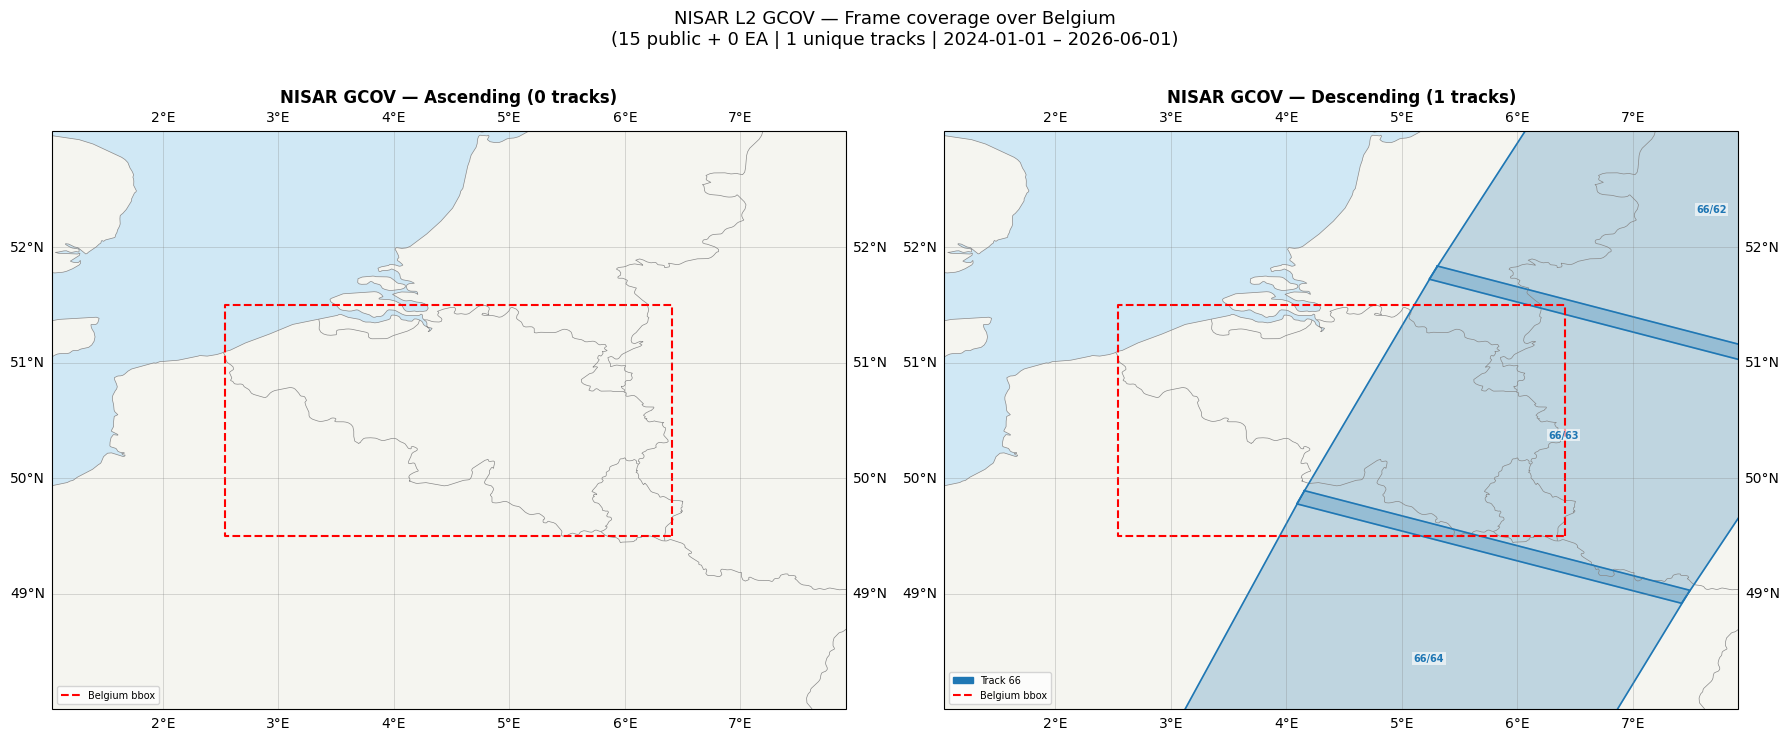

In [10]:
from shapely.geometry import box as shp_box

be_box = shp_box(BBOX_BELGIUM.west, BBOX_BELGIUM.south,
                  BBOX_BELGIUM.east, BBOX_BELGIUM.north)

PAD = 1.5
EXTENT = [
    BBOX_BELGIUM.west  - PAD,
    BBOX_BELGIUM.east  + PAD,
    BBOX_BELGIUM.south - PAD,
    BBOX_BELGIUM.north + PAD,
]
PROJ = ccrs.PlateCarree()


def make_track_colormap(tracks):
    tracks = sorted(set(t for t in tracks if t is not None))
    cmap   = plt.cm.get_cmap('tab20', max(len(tracks), 1))
    return {t: cmap(i) for i, t in enumerate(tracks)}


def plot_passes(ax, subset, track_colors, title):
    """Draw one representative footprint polygon per unique (track, frame)."""
    seen = set()
    for _, row in subset.iterrows():
        t   = row['track']
        fr  = row['frame']
        fp  = row['footprint']
        key = (t, fr)
        if fp is None or key in seen:
            continue
        seen.add(key)
        color = track_colors.get(t, 'grey')
        xs, ys = fp.exterior.xy
        ax.fill(xs, ys, alpha=0.25, color=color,  transform=PROJ)
        ax.plot(xs, ys, lw=1.2,    color=color,  transform=PROJ)
        cx, cy = fp.centroid.x, fp.centroid.y
        lbl = f'{t}/{fr}' if fr is not None else str(t)
        ax.text(cx, cy, lbl, ha='center', va='center', fontsize=7,
                fontweight='bold', color=color, transform=PROJ,
                bbox=dict(fc='white', ec='none', alpha=0.6, pad=1))

    bxs, bys = be_box.exterior.xy
    ax.plot(bxs, bys, 'r--', lw=1.5, transform=PROJ, label='Belgium bbox')

    ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0', zorder=0)
    ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f5', zorder=0)
    ax.add_feature(cfeature.BORDERS,   lw=0.5, edgecolor='#888888')
    ax.add_feature(cfeature.COASTLINE, lw=0.5, edgecolor='#888888')
    ax.gridlines(draw_labels=True, lw=0.4, color='grey', alpha=0.5)
    ax.set_extent(EXTENT, crs=PROJ)
    ax.set_title(title, fontsize=12, fontweight='bold')

    unique_tracks = sorted({row['track'] for _, row in subset.iterrows()
                             if row['track'] is not None})
    handles = [mpatches.Patch(color=track_colors.get(t, 'grey'), label=f'Track {t}')
               for t in unique_tracks]
    handles.append(plt.Line2D([0], [0], color='r', ls='--', label='Belgium bbox'))
    ax.legend(handles=handles, loc='lower left', fontsize=7,
              framealpha=0.8, ncol=max(1, len(unique_tracks) // 6))
    return unique_tracks


# ── Build plots ──────────────────────────────────────────────────────────────
df_valid = df.dropna(subset=['track', 'footprint'])
df_asc   = df_valid[df_valid['orbit_state'] == 'ascending']
df_desc  = df_valid[df_valid['orbit_state'] == 'descending']

all_tracks   = list(df_valid['track'].unique())
track_colors = make_track_colormap(all_tracks)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': PROJ})

n_asc  = plot_passes(axes[0], df_asc,  track_colors,
                     f'NISAR GCOV — Ascending ({len(df_asc["track"].unique())} tracks)')
n_desc = plot_passes(axes[1], df_desc, track_colors,
                     f'NISAR GCOV — Descending ({len(df_desc["track"].unique())} tracks)')

n_public = len(items_public)
n_ea     = len(items_ea)
plt.suptitle(
    f'NISAR L2 GCOV — Frame coverage over Belgium\n'
    f'({n_public:,} public + {n_ea:,} EA | {len(all_tracks)} unique tracks | '
    f'{START_DATE} – {END_DATE})',
    fontsize=13,
)
plt.tight_layout()
plt.show()